### CÉLULA 1: IMPORTANDO AS BIBLIOTECAS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv 

### CÉLULA 2: CARREGANDO OS DADOS DO DATASET

In [2]:
def carregar_dados(arquivo):
    X, y = [], []
    with open(arquivo, 'r') as f:
        leitor = csv.reader(f)
        next(leitor) # pular cabeçalho
        for linha in leitor:
            X.append([float(linha[0]), float(linha[1])]) # idade, salario
            y.append(int(linha[2]))
        return np.array(X), np.array(y)
    
# Carregando o dataset
X, y = carregar_dados("train_dataset1.csv")
print("Formato dos dados: ", X.shape, y.shape)
print("Primeiras amostras: \n", X[:5], "\nRótulos: ", y[:5])

Formato dos dados:  (140, 2) (140,)
Primeiras amostras: 
 [[ 0.25401832 -0.4023906 ]
 [ 0.18088266  0.5108872 ]
 [ 0.22715201  0.46771486]
 [-0.12283202  0.50263486]
 [ 0.43719255 -0.57959177]] 
Rótulos:  [-1  1  1  1 -1]


### CÉLULA 3: DECLARAÇÃO DA CLASSE, INICIALIZAÇÃO DOS PESOS, DECLARAÇÃO DO MÉTODO FIT, DECLARAÇÃO DO MÉTODO PARA VER O RESULTADO DO TREINAMENTO, DECLARAÇÃO DO MÉTODO PREDICT e MÉTODO PARA PLOTAR A CURVA DE ERROS

In [3]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=1000, weight_init="random"):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.weight_init = weight_init
        self.bias = None
        self.errors_per_epoch = [] # Armazena o erro a cada época

    # Inicializando os pesos de forma customizada
    def _initialize_weights(self, n_features):
        """ Inicializa os pesos de acordo com o método escolhido """
        if self.weight_init == "random":
            self.weights = np.random.rand(n_features)
            self.bias = np.random.rand()
        elif self.weight_init == "zeros":
            self.weights = np.zeros(n_features)
            self.bias = 0
        elif self.weight_init == "normal":
            self.weights = np.random.randn(n_features) * 0.01 # Pequenos valores gaussianos
            self.bias = np.random.randn() * 0.01
        else:
            raise ValueError("Opção inválida para inicialização dos pesos")
        
        # Declaração do método fit
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # self.weights = np.zeros(n_features)
        self._initialize_weights(n_features) # Inicializa os pesos dinamicamente
        self.bias = 0

        for epoch in range(self.n_epochs):
            errors = 0 # Contador de erros por época

            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = np.sign(linear_output)

                # Atualização dos pesos se houver erro
                if y_pred != y[i]:
                    self.weights += self.learning_rate * y[i] * X[i]
                    self.bias += self.learning_rate * y[i]
                    errors += 1 # Incrementa erro se classificação errada
            
            # Armazena a taxa de erro (erros / total de amostras)
            self.errors_per_epoch.append(errors / n_samples)

            # Parada antecipada se não houver erros
            if errors == 0:
                break
        
        # Após o treinamento, calcular e exibir estatísticas
        self._print_training_summary(X, y, epoch + 1)

    # Método para exibir a acurácia e pesos finais
    def _print_training_summary(self, X, y, epochs):
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print("\n==== Resumo do Treinamento ====")
        print(f"Acurácia no conjunto de treino: {accuracy:.2f}%")
        print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("====================================\n")

    # Retorna a predição com base no treinamento do Perceptron
    def predict(self, X):
        return np.sign(np.dot(X, self.weights) + self.bias)
    
    # Faz previsões e, se os rótulos forem fornecidos, exibe métricas
    def predict2(self, X, y, y_true=None):
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)

        # Se y_true for fornecido, calcular métricas de avaliação
        if y_true is not None:
            self.predict_summary(X, y_true, 0, "Teste")

        return y_pred
    
    # Calculando as métricas da predição
    def predict_summary(self, X, y, epochs, phase):
        """ Método para exibir a acurácia, desvio padrão e pesos finais """
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print(f"\n==== Resumo do {phase} ====")
        print(f"Acurácia no conjunto de {phase.lower()}: {accuracy:.2f}%")
        print(f"Desvio Padrão dos Pesos: {std_dev:.5f}")
        if epochs > 0:
            print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("====================================\n")

    # Plota o gráfico da evolução dos erros ao longo das épocas de treinamento.
    def plot_error(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.errors_per_epoch, marker='o', linestyle='-')
        plt.xlabel("Época")
        plt.ylabel("Taxa de erro")
        plt.title("Evolução do erro ao longo das épocas")
        plt.grid()
        plt.show()

### CÉLULA 4: FUNÇÃO PARA PLOTAR A FRONTEIRA DE DECISÃO

In [4]:
# Gráfico da "fronteira" gerado pelo Perceptron
def plot_decision_boundary(X, y, model, title="Fronteira de Decisão do Perceptron"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Criar o gráfico
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.show()

### CÉLULA 5: DECLARAÇÃO DO MÉTODO PLOT_COMPARISON

In [5]:
# Função para plotar lado a lado: dataset e fronteira de decisão
def plot_comparison(X, y, model):
    # Criar uma grade para o plano cartesiano
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Criar os subplots (1 linha, 2 colunas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Subplot 1 - Fronteira de Decisão
    axes[0].contourf(xx, yy, Z, alpha=0.3)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    axes[0].set_xlabel("X1")
    axes[0].set_ylabel("X2")
    axes[0].set_title("Fronteira de Decisão do Perceptron")

    # Subplot 2 - Apenas os Dados
    axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    axes[1].set_xlabel("X1")
    axes[1].set_ylabel("X2")
    axes[1].set_title("Distribuição dos Dados do Dataset")

    plt.tight_layout()
    plt.show()

### CÉLULA 6: TREINANDO O PERCEPTRON COM OS DADOS DO DATASET 1


==== Resumo do Treinamento ====
Acurácia no conjunto de treino: 95.71%
Número total de épocas: 100
Pesos finais aprendidos: [-0.64674778  0.73811968]
Bias final: 0.30000000000000004



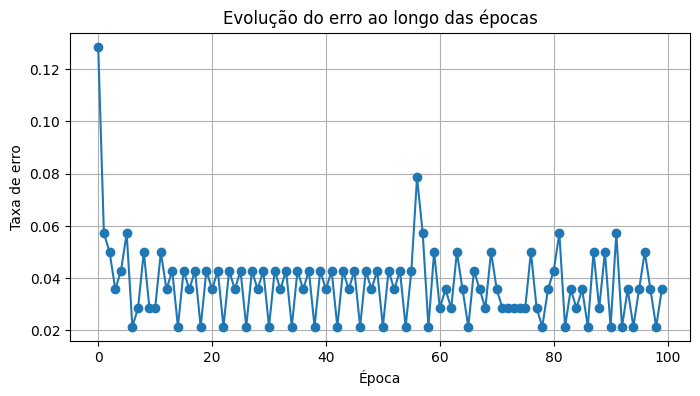

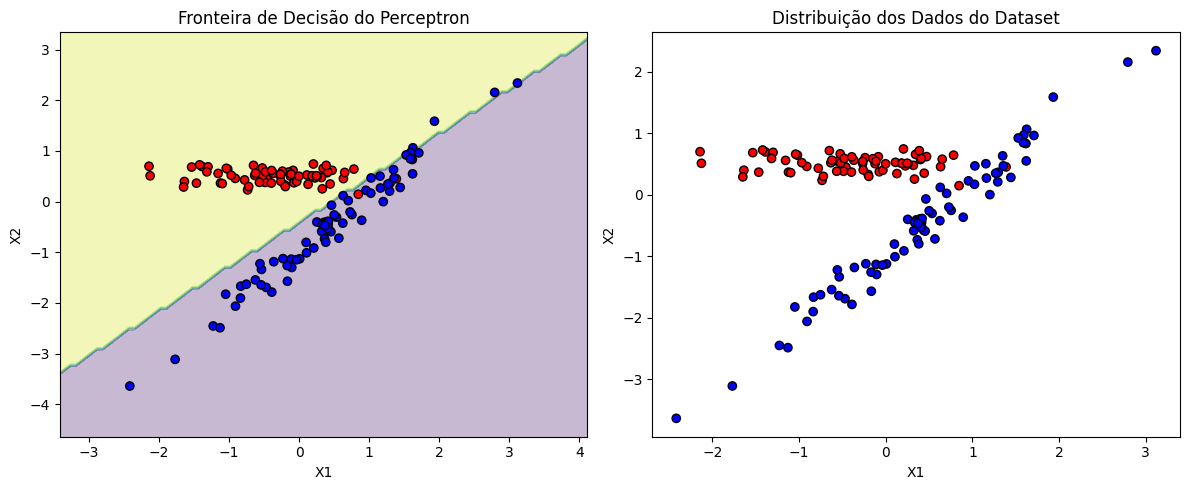

In [9]:
# Dataset 1 - Importando e visualizando o dataset de Treino
train_dataset1 = np.loadtxt("train_dataset1.csv", delimiter=",", skiprows=1, dtype=float)

# Definição das entradas
X = train_dataset1[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset1[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer previsões
y_pred = perceptron.predict2(X, y)

# Plotar a evolução do erro
perceptron.plot_error()

print("")

# Plot dos gráficos lado a lado
plot_comparison(X, y, perceptron)

### CÉLULA 7: TESTANDO O PERCEPTRON COM OS DADOS DO DATASET 1


==== Resumo do Teste ====
Acurácia no conjunto de teste: 93.33%
Desvio Padrão dos Pesos: 0.69243
Pesos finais aprendidos: [-0.64674778  0.73811968]
Bias final: 0.30000000000000004



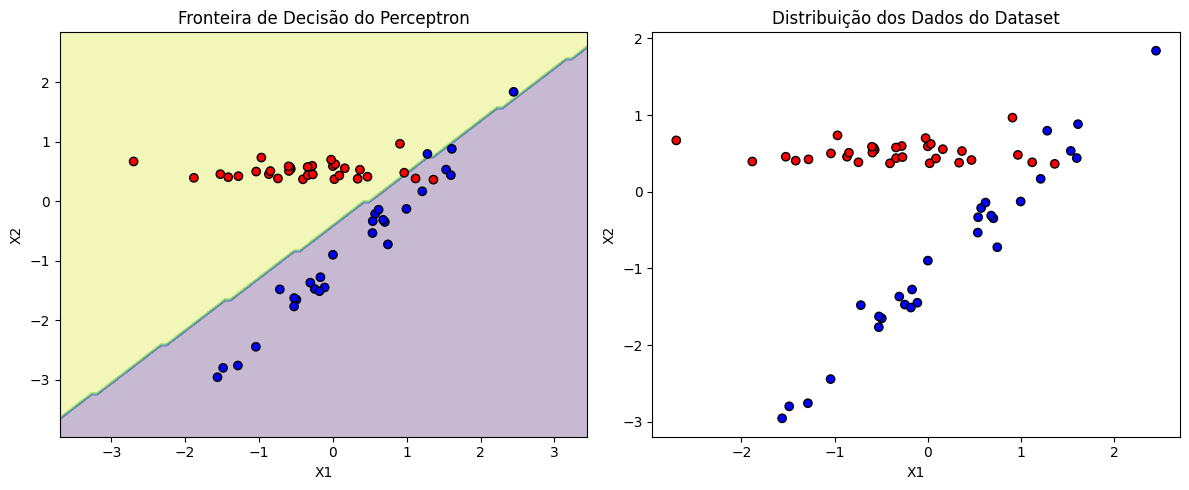

In [11]:
# Dataset 1 - Importando e visualizando o dataset de TESTE
test_dataset1 = np.loadtxt("test_dataset1.csv", delimiter=",", skiprows=1, dtype=float)

# Definição das entradas
X_test = test_dataset1[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y_test = test_dataset1[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y_test = np.where(y_test == -1, -1, 1)

# Fazer previsões
perceptron.predict2(X_test, y, y_test)

# Plot dos gráficos lado a lado
plot_comparison(X_test, y_test, perceptron)

### CÉLULA 8: TREINANDO O PERCEPTRON COM OS DADOS DO DATASET 2


==== Resumo do Treinamento ====
Acurácia no conjunto de treino: 48.00%
Número total de épocas: 100
Pesos finais aprendidos: [ 0.04032816 -0.08583517]
Bias final: 0.0



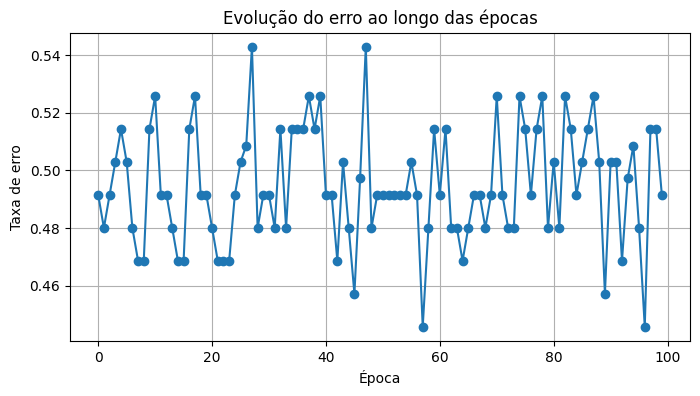

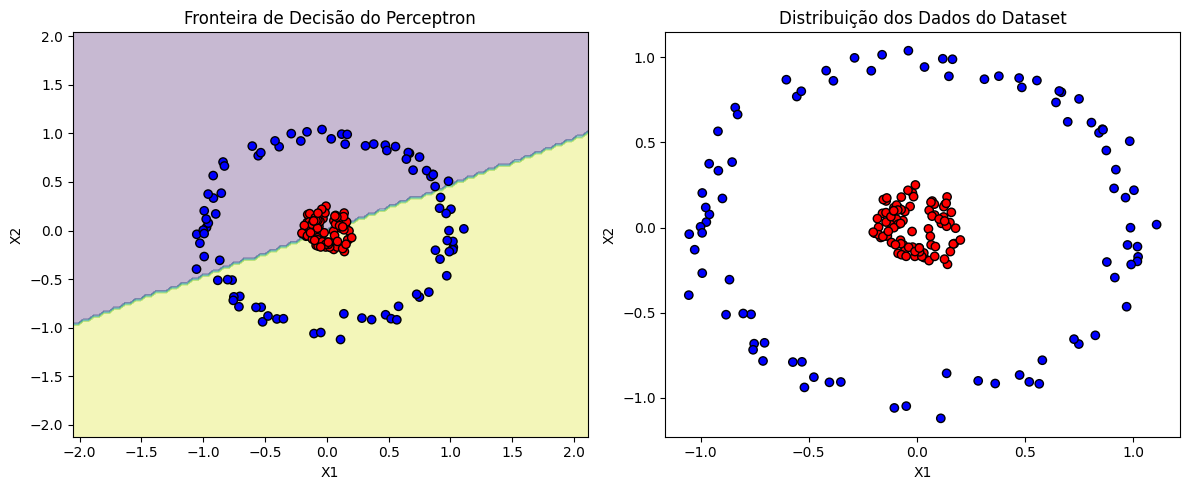

In [13]:
# Dataset 2 - Importando e visualizando o dataset de Treino
train_dataset2 = np.loadtxt("train_dataset2.csv", delimiter=",", skiprows=1, dtype=float)

# Definição das entradas
X = train_dataset2[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset2[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer previsões
y_pred = perceptron.predict2(X, y)

# Plotar a evolução do erro
perceptron.plot_error()

print("")

# Plot dos gráficos lado a lado
plot_comparison(X, y, perceptron)

### CÉLULA 9: TESTANDO O PERCEPTRON COM OS DADOS DO DATASET 2


==== Resumo do Teste ====
Acurácia no conjunto de teste: 49.33%
Desvio Padrão dos Pesos: 0.06308
Pesos finais aprendidos: [ 0.04032816 -0.08583517]
Bias final: 0.0



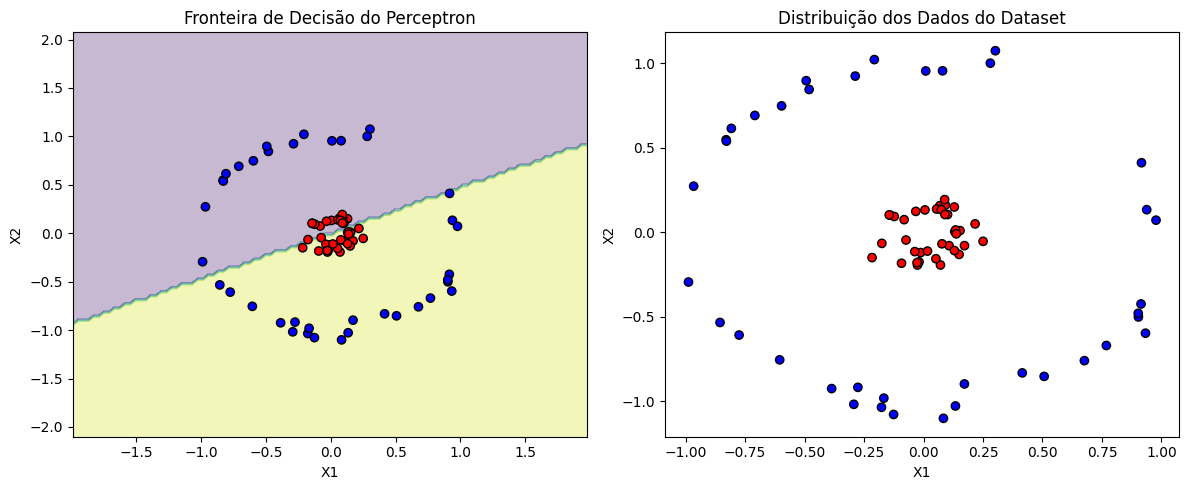

In [14]:
# Dataset 2 - Importando e visualizando o dataset de TESTE
test_dataset2 = np.loadtxt("test_dataset2.csv", delimiter=",", skiprows=1, dtype=float)

# Definição das entradas
X_test = test_dataset2[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y_test = test_dataset2[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y_test = np.where(y_test == -1, -1, 1)

# Fazer previsões
perceptron.predict2(X_test, y, y_test)

# Plot dos gráficos lado a lado
plot_comparison(X_test, y_test, perceptron)

### CÉLULA 10: TREINANDO O PERCEPTRON COM OS DADOS DO DATASET 3

Cenário 1 - Tx Treinamento: 0.1 | Épocas 100

==== Resumo do Treinamento ====
Acurácia no conjunto de treino: 91.84%
Número total de épocas: 100
Pesos finais aprendidos: [-0.15930037 -0.22729021 -0.33883513 -0.31746168  0.18261214 -0.0573935
  0.11453912  0.27955557  0.07126075  1.19646532]
Bias final: 2.7755575615628914e-17



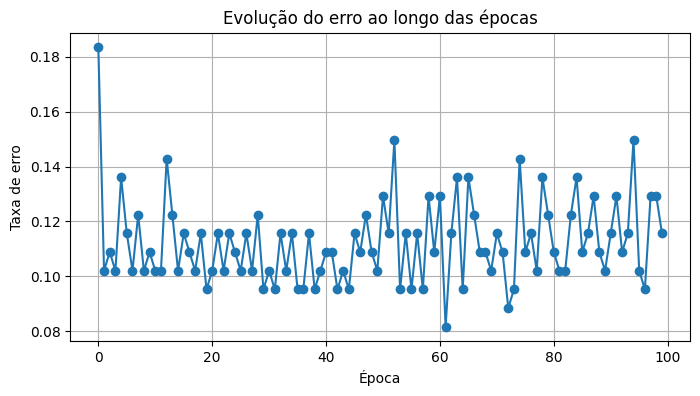


Cenário 2 - Tx Treinamento: 0.1 | Épocas 200

==== Resumo do Treinamento ====
Acurácia no conjunto de treino: 91.16%
Número total de épocas: 200
Pesos finais aprendidos: [-0.02745994 -0.17011097 -0.22211967 -0.11087934  0.264894   -0.11978642
 -0.09793986  0.2220734  -0.07153248  1.14998526]
Bias final: 2.7755575615628914e-17



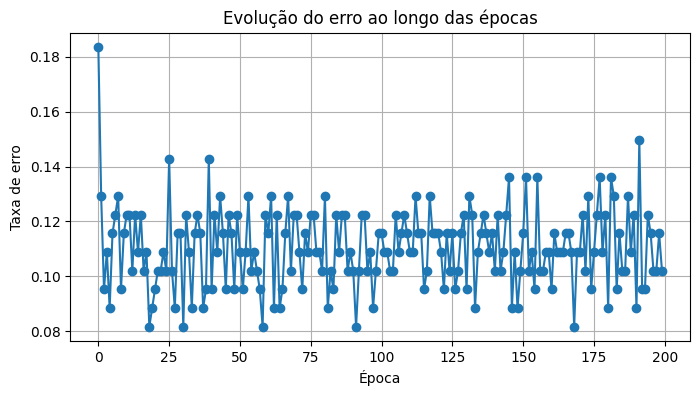


Cenário 3 - Tx Treinamento: 0.001 | Épocas 100

==== Resumo do Treinamento ====
Acurácia no conjunto de treino: 92.52%
Número total de épocas: 100
Pesos finais aprendidos: [ 0.0332938   0.0727353  -0.01290805  0.02567991  0.02698646 -0.0530552
  0.18316024  0.20682067 -0.1559294   0.66742971]
Bias final: -0.1290000000000001



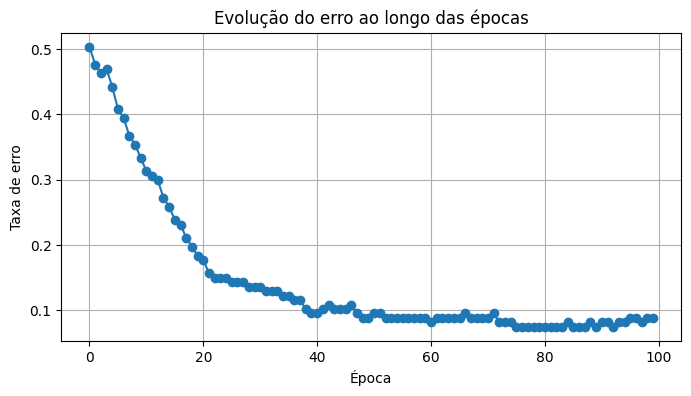


Cenário 4 - Tx Treinamento: 0.001 | Épocas 200

==== Resumo do Treinamento ====
Acurácia no conjunto de treino: 93.20%
Número total de épocas: 200
Pesos finais aprendidos: [ 0.06139395  0.00719387 -0.09478733 -0.02683557  0.01444778 -0.02610056
  0.07126035  0.15344302 -0.0229699   0.4261973 ]
Bias final: 0.007000000000000007



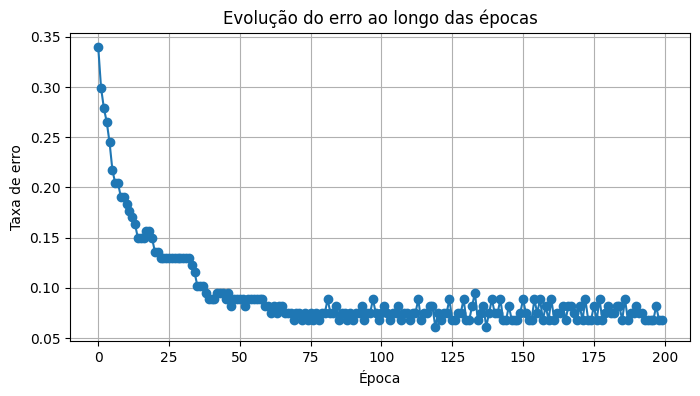


Cenário 5 - Tx Treinamento: 0.0001 | Épocas 100

==== Resumo do Treinamento ====
Acurácia no conjunto de treino: 78.91%
Número total de épocas: 100
Pesos finais aprendidos: [0.3121843  0.02597552 0.36977604 0.31949751 0.07384819 0.14004965
 0.59558997 0.32752365 0.00543639 0.62769708]
Bias final: -0.09970000000000183



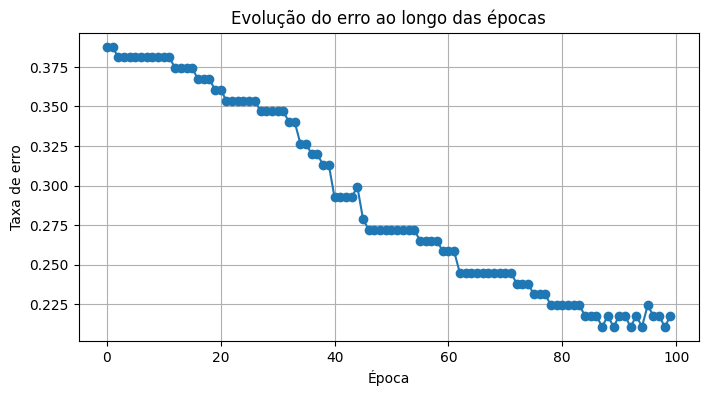


Cenário 6 - Tx Treinamento: 0.0001 | Épocas 200

==== Resumo do Treinamento ====
Acurácia no conjunto de treino: 77.55%
Número total de épocas: 200
Pesos finais aprendidos: [ 0.47230853  0.38745994  0.23037947  0.32672038  0.0396522   0.41885637
  0.66066664  0.61593944 -0.1814261   0.99817382]
Bias final: -0.13140000000000185



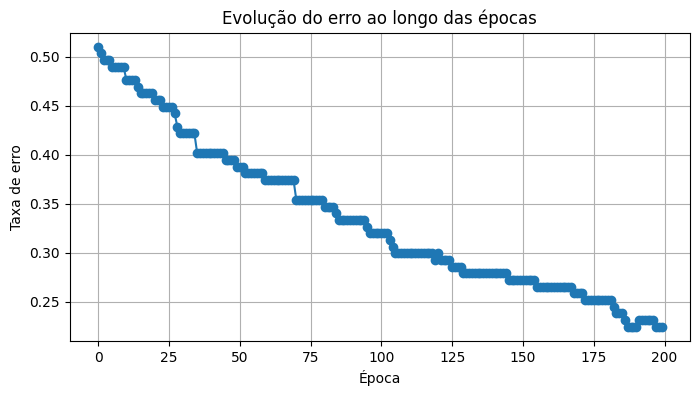

In [15]:
# Dataset 3 - Importando e visualizando o dataset de Treino
train_dataset3 = np.loadtxt("train_dataset3.csv", delimiter=",", skiprows=1, dtype=float)

# Definição das entradas
X = train_dataset3[:, :-1] # Todas as colunas, exceto a última (10 features)
y = train_dataset3[:, -1] # Última coluna é o rótulo
y = np.where(y == -1, -1, 1) # Converter rótulos para -1 e 1 (caso estejam diferentes)

# Criação do Perceptronde acordo com cenários da tabela
perceptron_cenario_1 = Perceptron(learning_rate=0.1, n_epochs=100)
perceptron_cenario_2 = Perceptron(learning_rate=0.1, n_epochs=200)
perceptron_cenario_3 = Perceptron(learning_rate=0.001, n_epochs=100)
perceptron_cenario_4 = Perceptron(learning_rate=0.001, n_epochs=200)
perceptron_cenario_5 = Perceptron(learning_rate=0.0001, n_epochs=100)
perceptron_cenario_6 = Perceptron(learning_rate=0.0001, n_epochs=200)

print("Cenário 1 - Tx Treinamento: 0.1 | Épocas 100")

# Treinamento do Perceptron
perceptron_cenario_1.fit(X, y)

# Plotar a evolução do erro
perceptron_cenario_1.plot_error()
print("")

print("Cenário 2 - Tx Treinamento: 0.1 | Épocas 200")

# Treinamento do Perceptron
perceptron_cenario_2.fit(X, y)

# Plotar a evolução do erro
perceptron_cenario_2.plot_error()
print("")

print("Cenário 3 - Tx Treinamento: 0.001 | Épocas 100")

# Treinamento do Perceptron
perceptron_cenario_3.fit(X, y)

# Plotar a evolução do erro
perceptron_cenario_3.plot_error()
print("")

print("Cenário 4 - Tx Treinamento: 0.001 | Épocas 200")

# Treinamento do Perceptron
perceptron_cenario_4.fit(X, y)

# Plotar a evolução do erro
perceptron_cenario_4.plot_error()
print("")

print("Cenário 5 - Tx Treinamento: 0.0001 | Épocas 100")

# Treinamento do Perceptron
perceptron_cenario_5.fit(X, y)

# Plotar a evolução do erro
perceptron_cenario_5.plot_error()
print("")

print("Cenário 6 - Tx Treinamento: 0.0001 | Épocas 200")

# Treinamento do Perceptron
perceptron_cenario_6.fit(X, y)

# Plotar a evolução do erro
perceptron_cenario_6.plot_error()
print("")



### CÉLULA 11: TESTANDO O PERCEPTRON COM OS DADOS DO DATASET 3

In [16]:
# Dataset 3 - Importando e visualizando o dataset de TESTE
test_dataset3 = np.loadtxt("test_dataset3.csv", delimiter=",", skiprows=1, dtype=float)

# Definição das entradas
X_test = test_dataset3[:, :-1] # Todas as colunas, exceto a última (10 features)
y_test = test_dataset3[:, -1] # Última coluna é o rótulo
y_test = np.where(y_test == -1, -1, 1) # Converter rótulos para -1 e 1 (caso estejam diferentes)

# Criação do Perceptronde acordo com cenários da tabela
perceptron_cenario_1 = Perceptron(learning_rate=0.1, n_epochs=100)
perceptron_cenario_2 = Perceptron(learning_rate=0.1, n_epochs=200)
perceptron_cenario_3 = Perceptron(learning_rate=0.001, n_epochs=100)
perceptron_cenario_4 = Perceptron(learning_rate=0.001, n_epochs=200)
perceptron_cenario_5 = Perceptron(learning_rate=0.0001, n_epochs=100)
perceptron_cenario_6 = Perceptron(learning_rate=0.0001, n_epochs=200)

print("Cenário 1 - Tx Teste: 0.1 | Épocas 100")

# Fazer previsões
perceptron_cenario_1.predict2(X_test, y, y_test)

print("")

print("Cenário 2 - Tx Teste: 0.1 | Épocas 200")

# Fazer previsões
perceptron_cenario_2.predict2(X_test, y, y_test)

print("")

print("Cenário 3 - Tx Teste: 0.001 | Épocas 100")

# Fazer previsões
perceptron_cenario_3.predict2(X_test, y, y_test)

print("")

print("Cenário 4 - Tx Teste: 0.001 | Épocas 200")

# Fazer previsões
perceptron_cenario_4.predict2(X_test, y, y_test)

print("")

print("Cenário 5 - Tx Teste: 0.0001 | Épocas 100")

# Fazer previsões
perceptron_cenario_5.predict2(X_test, y, y_test)

print("")

print("Cenário 6 - Tx Teste: 0.0001 | Épocas 200")

# Fazer previsões
perceptron_cenario_6.predict2(X_test, y, y_test)

print("")



Cenário 1 - Tx Teste: 0.1 | Épocas 100


TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'